In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(123)


n_samples=1000
class_0_ratio=0.9
n_class_0=int(n_samples*class_0_ratio)
n_class_1=n_samples-n_class_0



In [3]:
class_0=pd.DataFrame({
    'f_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'f_2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})

class_1=pd.DataFrame({
    'f_1':np.random.normal(loc=2,scale=1,size=n_class_1),
    'f_2':np.random.normal(loc=2,scale=1,size=n_class_1),
    'target':[1]*n_class_1
})

df=pd.concat([class_0,class_1]).reset_index(drop=True)
df

,f_1,f_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0
...,...,...,...
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1


<Axes: xlabel='f_1', ylabel='f_2'>

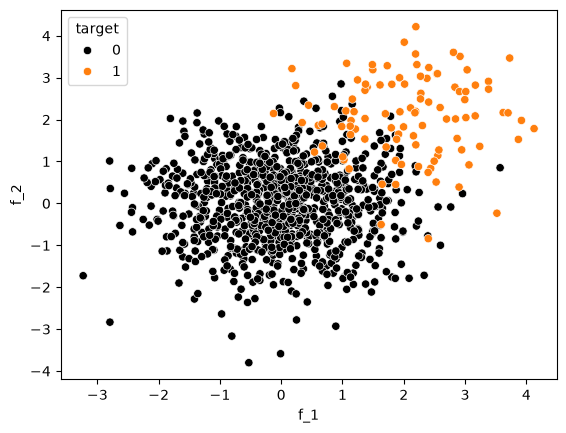

In [4]:
sns.scatterplot(data=df,x='f_1', y='f_2', hue='target', palette={0:'#000000', 1:'#ff7f0e'})

In [5]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [6]:
df_majority=df[df['target']==0]
df_minority=df[df['target']==1]


from sklearn.utils import resample

df_minority_upsampled=resample(df_minority,replace=True, n_samples=len(df_majority), random_state=42)

df_updated=pd.concat([df_majority,df_minority_upsampled])
df_updated

,f_1,f_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0
...,...,...,...
952,1.188902,2.189189,1
965,3.919526,1.980541,1
976,2.810326,3.604614,1
942,3.621531,2.168229,1


## Down sampling

In [7]:
df1=df
df1_majority=df1[df['target']==0]
df1_minority=df1[df['target']==1]


from sklearn.utils import resample

df1_majority_downsampled=resample(df1_majority,replace=True, n_samples=len(df1_minority), random_state=42)

df1_updated=pd.concat([df1_majority_downsampled,df1_minority])
df1_updated

,f_1,f_2,target
102,0.712265,0.718151,0
435,1.199988,0.574621,0
860,0.304515,-0.759475,0
270,-1.213385,0.675504,0
106,0.179549,-0.202659,0
...,...,...,...
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1


<Axes: xlabel='f_1', ylabel='f_2'>

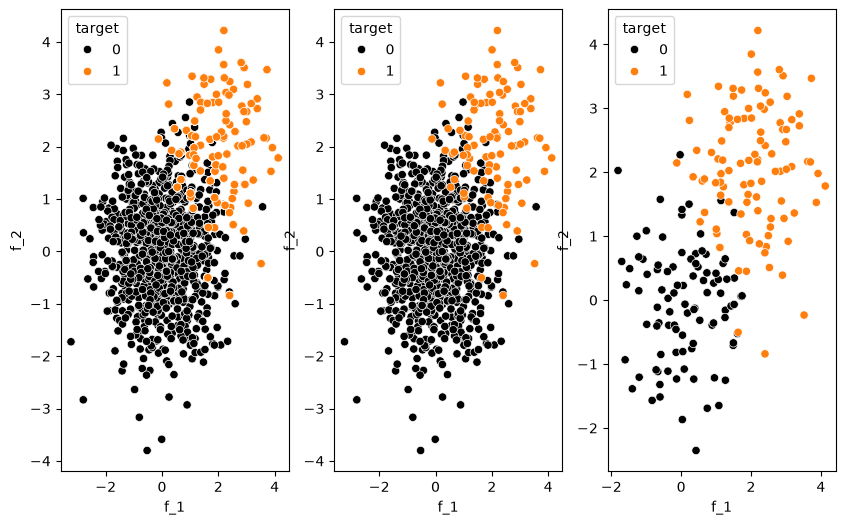

In [8]:
plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
sns.scatterplot(data=df_updated,x='f_1', y='f_2', hue='target', palette={0:'#000000', 1:'#ff7f0e'})
plt.subplot(1,3,2)
sns.scatterplot(data=df,x='f_1', y='f_2', hue='target', palette={0:'#000000', 1:'#ff7f0e'})
plt.subplot(1,3,3)
sns.scatterplot(data=df1_updated,x='f_1', y='f_2', hue='target', palette={0:'#000000', 1:'#ff7f0e'})

SMOTE

In [9]:
from sklearn.datasets import make_classification

X,y=make_classification(n_samples=1000,n_features=2,n_redundant=0,n_clusters_per_class=1,random_state=12, weights=[0.90])
X,y

(array([[-0.76289759, -0.70680807],
        [-1.07543571, -1.0511621 ],
        [-0.61011459, -0.90980157],
        ...,
        [-1.32643852, -1.815178  ],
        [-0.83348573, -0.5146474 ],
        [-0.30287558, -0.57597532]], shape=(1000, 2)),
 array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
        0, 0

In [10]:
import pandas as pd

df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2], axis=1)

final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


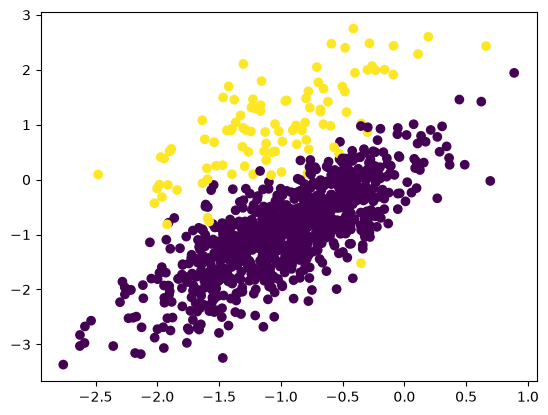

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [12]:
!pip install imblearn

In [13]:
from imblearn.over_sampling import SMOTE

In [ ]:
oversample=SMOTE()
X,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

X.shape
                                                   

(1800, 2)

In [15]:
y.shape

(1800,)

In [18]:
len(y[y==0])

900

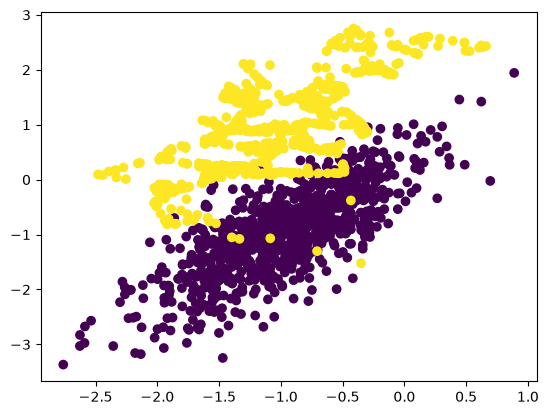

In [19]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2], axis=1)

plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])